# Time series 10: HAC + LSTM (hierarchical clustering for spectrum prediction)

Implements the approach from **Liu et al. (2021)** — *Hierarchical Agglomerative Clustering and LSTM-based Load Prediction for Dynamic Spectrum Allocation* (IEEE CCNC).

- **Problem**: Multi-series prediction (one series per sensor/channel). Directly applying LSTM to all series can reduce accuracy when some series are uncorrelated.
- **HAC (Hierarchical Agglomerative Clustering)** based on **Spearman's rank correlation coefficient (SRCC)**: distance = 1 − |r_s|; **complete linkage** so that series in a cluster are all correlated. Correlated channels are grouped; uncorrelated ones stay separate.
- **Per-cluster LSTM**: One LSTM is trained per cluster on the channels in that cluster; prediction is done independently per cluster and results are reassembled.
- **Low-pass filter** (optional): Pre-process data to remove high-frequency noise and improve correlation/prediction (paper uses cutoff 0.5).
- **Evaluation**: MAPE and RMSE (paper metrics).

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)

Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
T_total = Z.shape[0]

print(f"Loaded {len(df)} rows. Channels (series): {N}")
print(f"Matrix shape: (T={T_total}, N={N})")

Loaded 9192 rows. Channels (series): 70
Matrix shape: (T=9192, N=70)


## Train / validation / test split (6 : 1 : 3) and optional low-pass filter

Same split as time_series_8 and 9: 60% train, 10% validation, 30% test. Optional **low-pass filter** (paper: cutoff 0.5) is applied per channel to smooth high-frequency noise.

In [8]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

USE_LOWPASS = True
CUTOFF = 0.5  # normalized (paper uses 0.5)
FILTER_ORDER = 3

def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
    from scipy.signal import butter, filtfilt
    # Wn must be 0 < Wn < 1 for digital butter (1 = Nyquist). Paper cutoff 0.5 = normalized freq.
    normal_cutoff = min(float(cutoff), 0.99)
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    out = np.zeros_like(Z_mat)
    for j in range(Z_mat.shape[1]):
        out[:, j] = filtfilt(b, a, Z_mat[:, j])
    return out

if USE_LOWPASS:
    Z_full = lowpass_per_channel(Z, cutoff=CUTOFF, order=FILTER_ORDER)
    print(f"Applied low-pass filter (cutoff={CUTOFF}, order={FILTER_ORDER}).")
else:
    Z_full = Z.copy()

Z_train = Z_full[:n_train]
Z_val = Z_full[n_train : n_train + n_val]
Z_test = Z_full[n_train + n_val :]
print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Applied low-pass filter (cutoff=0.5, order=3).
Train: 5515, Val: 919, Test: 2758


## SRCC-based HAC (complete linkage)

Compute **Spearman rank correlation** between all pairs of channels (series) on **training** data. Distance = 1 − |r_s|. Run **hierarchical agglomerative clustering** with **complete linkage** until we have **n_clusters** clusters (or use a distance threshold).

## Visualize HAC clustering

Dendrogram (merge order), correlation heatmap reordered by cluster, and channel-to-cluster assignment.

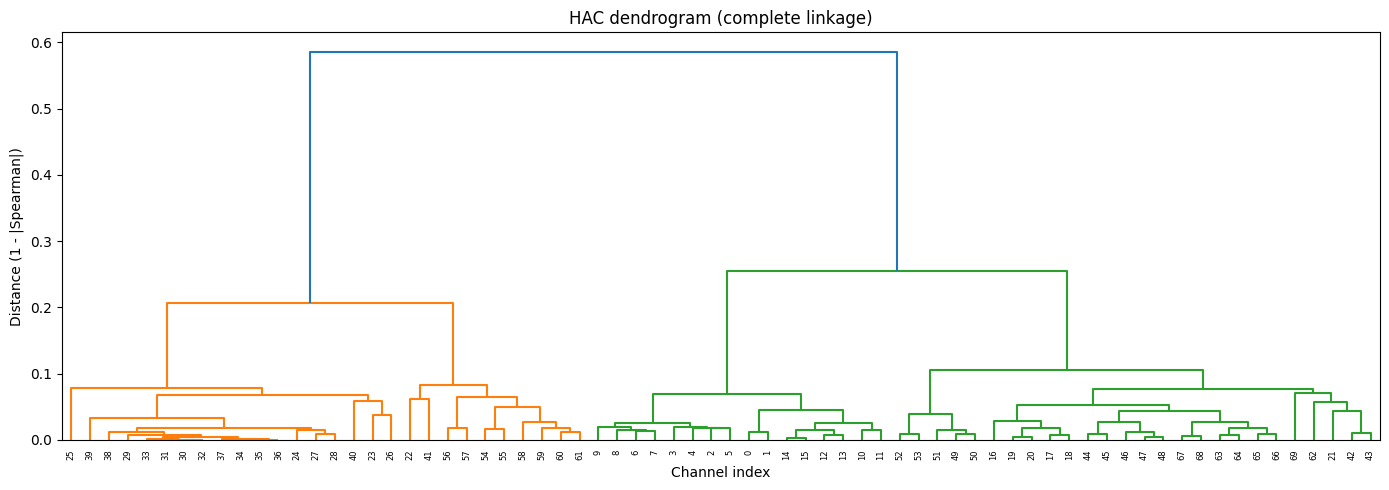

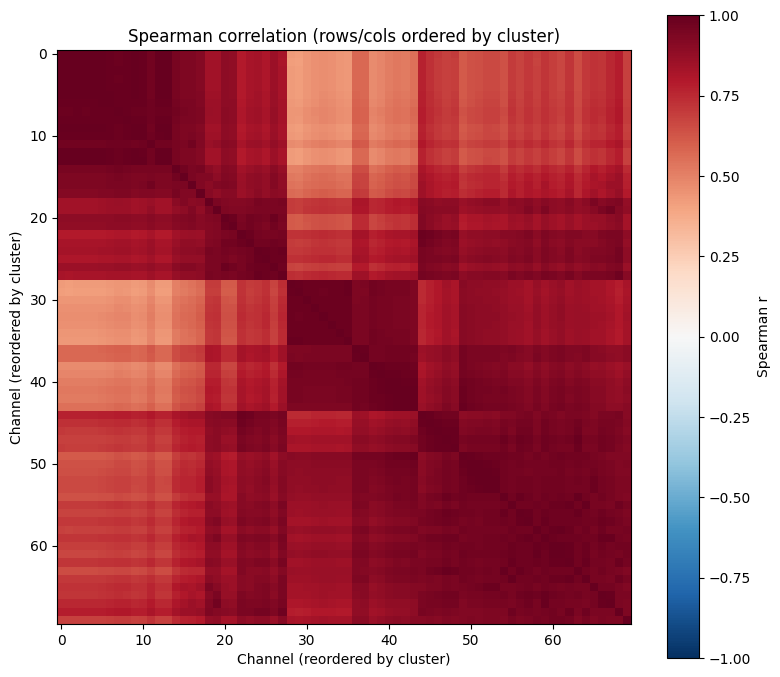

In [21]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# 1) Dendrogram (hierarchy of merges; horizontal to avoid crowding 70 leaves)
fig1, ax1 = plt.subplots(figsize=(14, 5))
dendrogram(Z_link, ax=ax1, leaf_rotation=90, leaf_font_size=6,
           color_threshold=0.7 * max(Z_link[:, 2]))
ax1.set_xlabel("Channel index")
ax1.set_ylabel("Distance (1 - |Spearman|)")
ax1.set_title("HAC dendrogram (complete linkage)")
plt.tight_layout()
plt.show()

# 2) Correlation heatmap with channels reordered by cluster (blocks = clusters)
order = np.argsort(labels)
rho_ord = rho[np.ix_(order, order)]
fig2, ax2 = plt.subplots(figsize=(8, 7))
im = ax2.imshow(rho_ord, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
ax2.set_xlabel("Channel (reordered by cluster)")
ax2.set_ylabel("Channel (reordered by cluster)")
ax2.set_title("Spearman correlation (rows/cols ordered by cluster)")
plt.colorbar(im, ax=ax2, label="Spearman r")
plt.tight_layout()
plt.show()

# 3) Channel-to-cluster assignment (hover to see cluster id)
import plotly.graph_objects as go
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
rgb = [f"rgb({int(colors[labels[j] % 20][0]*255)},{int(colors[labels[j] % 20][1]*255)},{int(colors[labels[j] % 20][2]*255)})" for j in range(N)]
# Include frequency band (e.g. 3.1–3.5 GHz) in hover
hovertext = [f"Channel {j} | {freq_bands[j]} | Cluster {labels[j]}" for j in range(N)]
fig3 = go.Figure(go.Bar(
    orientation="h",
    x=[1] * N,
    y=[0] * N,
    base=list(range(N)),
    marker_color=rgb,
    hovertext=hovertext,
    hoverinfo="text",
    showlegend=False,
))
fig3.update_layout(
    title="Channel → cluster (hover to see cluster id)",
    xaxis_title="Channel index",
    xaxis=dict(range=[0, N]),
    yaxis=dict(showticklabels=False, range=[-0.2, 0.5]),
    height=200,
    margin=dict(t=50, b=50),
)
# Display as HTML so it works without nbformat/mime renderer; hover still works
from IPython.display import display, HTML
display(HTML(fig3.to_html(include_plotlyjs="cdn")))

In [9]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

print("Computing SRCC matrix on training data...")
rho, _ = spearmanr(Z_train, axis=0, nan_policy="omit")
rho = np.nan_to_num(rho, nan=0.0)

# Distance: 1 - |r_s| (high correlation = small distance)
D = 1 - np.abs(rho)
np.fill_diagonal(D, 0)

# HAC with complete linkage
D_cond = squareform(D, checks=False)
Z_link = linkage(D_cond, method="complete")

n_clusters = max(2, min(20, N // 4))  # between 2 and 20, or N//4
labels = fcluster(Z_link, n_clusters, criterion="maxclust")
labels = labels - 1  # 0-based

clusters = [np.where(labels == c)[0] for c in range(n_clusters)]
cluster_sizes = [len(c) for c in clusters]
print(f"HAC complete linkage: {n_clusters} clusters.")
print(f"Cluster sizes: {cluster_sizes}")

Computing SRCC matrix on training data...
HAC complete linkage: 17 clusters.
Cluster sizes: [14, 2, 1, 1, 1, 1, 2, 2, 4, 8, 8, 5, 5, 11, 3, 1, 1]


## Per-cluster LSTM: sequences and training

Paper: use past 10 minutes (one slot) to predict the next one; we use past **SEQ_LEN** hours to predict the **next hour** (one step). For each cluster, build sequences from the channels in that cluster, train one LSTM (paper: 1 hidden layer, 32 units; we use 2 layers, 32 hidden), then at test time predict per cluster and reassemble.

In [10]:
import torch
import torch.nn as nn

SEQ_LEN = 24
HIDDEN = 32
EPOCHS = 100
BATCH = 64
LR = 5e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_sequences(Z_mat, indices, seq_len):
    """Z_mat (T, N_full). indices = channel indices in cluster. Return X (n, seq_len, n_c), Y (n, n_c)."""
    Z_c = Z_mat[:, indices]
    n_c = Z_c.shape[1]
    X_list, Y_list = [], []
    for i in range(seq_len, len(Z_c) - 1):
        X_list.append(Z_c[i - seq_len : i])
        Y_list.append(Z_c[i + 1])
    if not X_list:
        return None, None
    return np.array(X_list, dtype=np.float32), np.array(Y_list, dtype=np.float32)

class LSTMCluster(nn.Module):
    def __init__(self, n_in, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden, n_in)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

models = {}
for c in tqdm(range(n_clusters), desc="Training LSTM per cluster"):
    idx = clusters[c]
    X_c, Y_c = build_sequences(Z_train, idx, SEQ_LEN)
    if X_c is None or len(X_c) < 2:
        continue
    n_in = X_c.shape[2]
    model = LSTMCluster(n_in, hidden=HIDDEN).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    n_tr = len(X_c)
    batch_use = min(BATCH, n_tr)
    for _ in range(EPOCHS):
        model.train()
        perm = np.random.permutation(n_tr)
        for start in range(0, n_tr, batch_use):
            i = perm[start : start + batch_use]
            x = torch.from_numpy(X_c[i]).to(device)
            y = torch.from_numpy(Y_c[i]).to(device)
            pred = model(x)
            loss = nn.functional.l1_loss(pred, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
    models[c] = (model, idx)

print(f"Trained {len(models)} cluster LSTMs.")

# Save models and cluster config for reuse (skip retraining next time)
MODEL_DIR = _root / "data" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_DIR / "hac_lstm_model.pt"
ckpt = {
    "N": N,
    "SEQ_LEN": SEQ_LEN,
    "HIDDEN": HIDDEN,
    "n_clusters": n_clusters,
    "clusters": [clusters[c].tolist() for c in range(n_clusters)],
    "state_dicts": {c: models[c][0].state_dict() for c in models},
}
torch.save(ckpt, save_path)
print(f"Model and clusters saved to {save_path}")

Training LSTM per cluster:   0%|          | 0/17 [00:00<?, ?it/s]

Trained 17 cluster LSTMs.
Model and clusters saved to /Users/pradeep/workspace/nikhita/cablelabs/data/models/hac_lstm_model.pt


## Load saved model (optional)

Run the cell below **instead of** re-running HAC (cell 5) and per-cluster LSTM training (cell 7) to load a previously saved model from `data/models/hac_lstm_model.pt`. Run data + split (cells 1–3) and the LSTM class definition (cell 7) first; then run this cell and the test/baseline cells.

In [14]:
# Load saved HAC-LSTM model (skip HAC and LSTM training)
load_path = _root / "data" / "models" / "hac_lstm_model.pt"
if not load_path.exists():
    raise FileNotFoundError(f"No saved model at {load_path}. Run HAC and LSTM training cells first to save.")
ckpt = torch.load(load_path, map_location=device, weights_only=False)
N_ld = ckpt["N"]
SEQ_LEN_ld = ckpt["SEQ_LEN"]
HIDDEN_ld = ckpt["HIDDEN"]
n_clusters_ld = ckpt["n_clusters"]
clusters_ld = [np.array(idx_list) for idx_list in ckpt["clusters"]]

clusters = clusters_ld
n_clusters = n_clusters_ld
models = {}
for c, state in ckpt["state_dicts"].items():
    idx = clusters[c]
    n_in = len(idx)
    model = LSTMCluster(n_in, hidden=HIDDEN_ld).to(device)
    model.load_state_dict(state)
    model.eval()
    models[c] = (model, idx)

print(f"Loaded model from {load_path} ({n_clusters} clusters). Run test and baseline cells next.")

Loaded model from /Users/pradeep/workspace/nikhita/cablelabs/data/models/hac_lstm_model.pt (17 clusters). Run test and baseline cells next.


## Test: rolling prediction per cluster and reassembly

For each test step, use the last SEQ_LEN hours (from the full history including train) as input; predict next step per cluster; reassemble into (n_test, N) and compute MAPE and RMSE.

In [12]:
test_start = n_train + n_val  # test period starts after train + val
pred_test = np.full((n_test, N), np.nan, dtype=np.float64)

for t in range(n_test):
    global_idx = test_start + t
    start = global_idx - SEQ_LEN
    if start < 0:
        continue
    window = Z_full[start : global_idx]
    for c, (model, idx) in models.items():
        model.eval()
        x_c = torch.from_numpy(window[:, idx].astype(np.float32)).unsqueeze(0).to(device)
        with torch.no_grad():
            y_c = model(x_c).cpu().numpy().squeeze(0)
        pred_test[t, idx] = y_c

# Fill any channel without a model (unlikely) with persistence
nan_mask = np.isnan(pred_test)
if np.any(nan_mask):
    for t in range(n_test):
        for j in range(N):
            if np.isnan(pred_test[t, j]):
                pred_test[t, j] = Z_full[test_start + t - 1, j] if t > 0 else Z_full[test_start - 1, j]

valid = ~np.isnan(pred_test)
pred_flat = pred_test[valid]
true_flat = Z_test[valid]

mape = np.mean(np.abs((true_flat - pred_flat) / (np.abs(true_flat) + 1e-8))) * 100
rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))
mae = np.mean(np.abs(true_flat - pred_flat))

print("HAC-LSTM (test set):")
print(f"  MAPE = {mape:.4f}%")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")

# Naive: last observed value (persistence), same idea as time_series_8 and 9
pred_naive = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    pred_naive[t] = Z_full[test_start + t - 1] if t > 0 else Z_full[test_start - 1]
mape_naive = np.mean(np.abs((Z_test - pred_naive) / (np.abs(Z_test) + 1e-8))) * 100
rmse_naive = np.sqrt(np.mean((Z_test - pred_naive) ** 2))
mae_naive = np.mean(np.abs(Z_test - pred_naive))
print("Naive (last value repeated):")
print(f"  MAPE = {mape_naive:.4f}%, RMSE = {rmse_naive:.4f}, MAE = {mae_naive:.4f}")

HAC-LSTM (test set):
  MAPE = 22.0896%
  RMSE = 11.1188
  MAE  = 6.2027
Naive (last value repeated):
  MAPE = 13.0105%, RMSE = 4.5277, MAE = 2.7672


## Baseline: single LSTM on all channels (no clustering)

Train one LSTM on all N channels; same SEQ_LEN and architecture. Paper shows that uncorrelated series can reduce accuracy; we compare MAPE and RMSE.

LSTM on all channels (baseline):   0%|          | 0/100 [00:00<?, ?it/s]

LSTM on all channels (no HAC):
  MAPE = 53.4329%
  RMSE = 21.9768
  MAE  = 14.4473
Comparison: HAC-LSTM vs LSTM only vs Naive
  MAPE: HAC-LSTM = 22.0896%,  LSTM only = 53.4329%,  Naive = 13.0105%
  RMSE: HAC-LSTM = 11.1188,  LSTM only = 21.9768,  Naive = 4.5277
  MAE:  HAC-LSTM = 6.2027,  LSTM only = 14.4473,  Naive = 2.7672


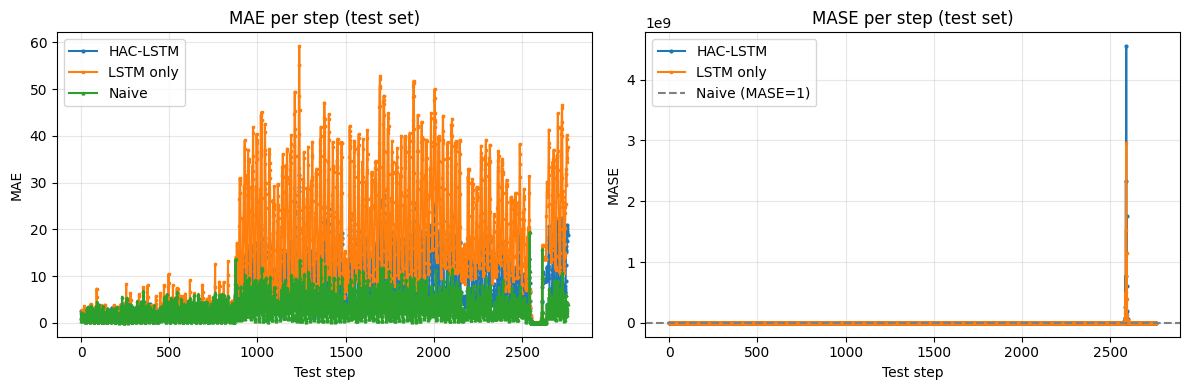

In [13]:
X_all, Y_all = build_sequences(Z_train, np.arange(N), SEQ_LEN)
if X_all is not None and len(X_all) >= BATCH:
    model_all = LSTMCluster(N, hidden=HIDDEN).to(device)
    opt_all = torch.optim.Adam(model_all.parameters(), lr=LR)
    n_tr = len(X_all)
    batch_use = min(BATCH, n_tr)
    for _ in tqdm(range(EPOCHS), desc="LSTM on all channels (baseline)"):
        model_all.train()
        perm = np.random.permutation(n_tr)
        for start in range(0, n_tr, batch_use):
            i = perm[start : start + batch_use]
            x = torch.from_numpy(X_all[i]).to(device)
            y = torch.from_numpy(Y_all[i]).to(device)
            pred = model_all(x)
            loss = nn.functional.l1_loss(pred, y)
            opt_all.zero_grad()
            loss.backward()
            opt_all.step()

    test_start = n_train + n_val
    pred_baseline = np.zeros((n_test, N), dtype=np.float64)
    for t in range(n_test):
        global_idx = test_start + t
        start = global_idx - SEQ_LEN
        if start < 0:
            continue
        x = torch.from_numpy(Z_full[start:global_idx].astype(np.float32)).unsqueeze(0).to(device)
        model_all.eval()
        with torch.no_grad():
            pred_baseline[t] = model_all(x).cpu().numpy().squeeze(0)

    valid_b = np.ones_like(Z_test, dtype=bool)  # baseline predicts all channels
    mape_b = np.mean(np.abs((Z_test[valid_b] - pred_baseline[valid_b]) / (np.abs(Z_test[valid_b]) + 1e-8))) * 100
    rmse_b = np.sqrt(np.mean((Z_test[valid_b] - pred_baseline[valid_b]) ** 2))
    mae_b = np.mean(np.abs(Z_test - pred_baseline))
    print("LSTM on all channels (no HAC):")
    print(f"  MAPE = {mape_b:.4f}%")
    print(f"  RMSE = {rmse_b:.4f}")
    print(f"  MAE  = {mae_b:.4f}")

    # Final comparison: HAC-LSTM vs LSTM only vs Naive (same style as time_series_8 and 9)
    if "mape_naive" in dir():
        print("Comparison: HAC-LSTM vs LSTM only vs Naive")
        print(f"  MAPE: HAC-LSTM = {mape:.4f}%,  LSTM only = {mape_b:.4f}%,  Naive = {mape_naive:.4f}%")
        print(f"  RMSE: HAC-LSTM = {rmse:.4f},  LSTM only = {rmse_b:.4f},  Naive = {rmse_naive:.4f}")
        print(f"  MAE:  HAC-LSTM = {mae:.4f},  LSTM only = {mae_b:.4f},  Naive = {mae_naive:.4f}")

        # MAE and MASE per test step (like ts8/ts9)
        import matplotlib.pyplot as plt
        maes_hac = [float(np.mean(np.abs(Z_test[t] - pred_test[t]))) for t in range(n_test)]
        maes_baseline = [float(np.mean(np.abs(Z_test[t] - pred_baseline[t]))) for t in range(n_test)]
        maes_naive_d = [float(np.mean(np.abs(Z_test[t] - pred_naive[t]))) for t in range(n_test)]
        mase_hac = [maes_hac[t] / (maes_naive_d[t] + 1e-12) for t in range(n_test)]
        mase_baseline = [maes_baseline[t] / (maes_naive_d[t] + 1e-12) for t in range(n_test)]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        steps = list(range(1, n_test + 1))
        ax1.plot(steps, maes_hac, "o-", label="HAC-LSTM", markersize=2)
        ax1.plot(steps, maes_baseline, "s-", label="LSTM only", markersize=2)
        ax1.plot(steps, maes_naive_d, "^-", label="Naive", markersize=2)
        ax1.set_xlabel("Test step")
        ax1.set_ylabel("MAE")
        ax1.set_title("MAE per step (test set, full range)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax2.plot(steps, mase_hac, "o-", label="HAC-LSTM", markersize=2)
        ax2.plot(steps, mase_baseline, "s-", label="LSTM only", markersize=2)
        ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
        ax2.set_xlabel("Test step")
        ax2.set_ylabel("MASE")
        ax2.set_title("MASE per step (test set, full range)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Zoomed view (first 400 steps) for readability
        zoom_steps = min(400, n_test)
        steps_zoom = list(range(1, zoom_steps + 1))
        fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
        ax3.plot(steps_zoom, maes_hac[:zoom_steps], "o-", label="HAC-LSTM", markersize=4)
        ax3.plot(steps_zoom, maes_baseline[:zoom_steps], "s-", label="LSTM only", markersize=4)
        ax3.plot(steps_zoom, maes_naive_d[:zoom_steps], "^-", label="Naive", markersize=4)
        ax3.set_xlabel("Test step")
        ax3.set_ylabel("MAE")
        ax3.set_title(f"MAE per step (zoomed: first {zoom_steps} steps)")
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax4.plot(steps_zoom, mase_hac[:zoom_steps], "o-", label="HAC-LSTM", markersize=4)
        ax4.plot(steps_zoom, mase_baseline[:zoom_steps], "s-", label="LSTM only", markersize=4)
        ax4.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
        ax4.set_xlabel("Test step")
        ax4.set_ylabel("MASE")
        ax4.set_title(f"MASE per step (zoomed: first {zoom_steps} steps)")
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Not enough sequences for baseline LSTM.")